In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
#Carichiamo il dataset e visualizziamo un anteprima

dataset_path = 'dataset/Base.csv'
data = pd.read_csv(dataset_path)

print(data.head())

   fraud_bool  income  name_email_similarity  prev_address_months_count  \
0           0     0.3               0.986506                         -1   
1           0     0.8               0.617426                         -1   
2           0     0.8               0.996707                          9   
3           0     0.6               0.475100                         11   
4           0     0.9               0.842307                         -1   

   current_address_months_count  customer_age  days_since_request  \
0                            25            40            0.006735   
1                            89            20            0.010095   
2                            14            40            0.012316   
3                            14            30            0.006991   
4                            29            40            5.742626   

   intended_balcon_amount payment_type  zip_count_4w  ...  has_other_cards  \
0              102.453711           AA          1059  ..

In [6]:
#Analizziamo il dataset

print("Dataset Info:")
print(data.info())

print("\nClass Distribution:")
if 'fraud_bool' in data.columns:
    print(data['fraud_bool'].value_counts())

print("\nStatistiche:")
print(data.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  str    
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1

### Dati del Cliente
- **income**: Reddito annuo del richiedente (in quantili).
- **customer_age**: Età del richiedente raggruppata per decenni.
- **employment_status**: Stato occupazionale (valori anonimizzati).
- **housing_status**: Situazione abitativa (valori anonimizzati).
- **date_of_birth_distinct_emails_4w**: Numero di email diverse per stessa data di nascita (ultime 4 settimane).

### Dati della Richiesta
- **fraud_bool**: Etichetta di frode (1 = frode, 0 = legittimo).
- **intended_balcon_amount**: Importo iniziale del trasferimento.
- **proposed_credit_limit**: Limite di credito proposto dalla banca.
- **payment_type**: Tipologia di piano di pagamento.
- **days_since_request**: Giorni passati dalla compilazione della domanda.
- **month**: Mese in cui è stata effettuata la richiesta.
- **foreign_request**: Indica se la richiesta proviene da un paese estero.

### Verifiche di Identità e Rischio
- **credit_risk_score**: Punteggio interno di rischio dell'applicazione.
- **name_email_similarity**: Grado di somiglianza tra nome del richiedente ed email.
- **email_is_free**: Indica se il dominio dell'email è gratuito (es. Gmail).
- **phone_home_valid**: Validità del numero di telefono fisso.
- **phone_mobile_valid**: Validità del numero di cellulare.
- **has_other_cards**: Indica se il cliente ha altre carte con la stessa banca.
- **bank_months_count**: Anzianità (in mesi) del precedente conto bancario.

### Dati Tecnici e Dispositivo
- **source**: Canale della richiesta (Internet o App).
- **device_os**: Sistema operativo del dispositivo utilizzato.
- **session_length_in_minutes**: Durata della sessione sul sito in minuti.
- **keep_alive_session**: Opzione dell'utente sul logout della sessione.
- **device_distinct_emails_8w**: Email diverse usate dallo stesso dispositivo (ultime 8 settimane).
- **device_fraud_count**: Numero di frodi associate al dispositivo utilizzato.

### Metriche di Volume e Frequenza (Velocity)
- **zip_count_4w**: Numero di domande dallo stesso CAP (ultime 4 settimane).
- **velocity_6h / 24h / 4w**: Media delle domande per ora in vari archi temporali.
- **bank_branch_count_8w**: Numero di domande nella stessa filiale (ultime 8 settimane).
- **prev/current_address_months_count**: Mesi di permanenza presso l'indirizzo precedente o attuale.



1.000.000 entries, 32 colonne.

Notiamo che non ci sono valori mancanti o valori infiniti.

Ci sono 988971 transazioni legittime e 11029 transazioni fraudolente (dataset sbilanciato).

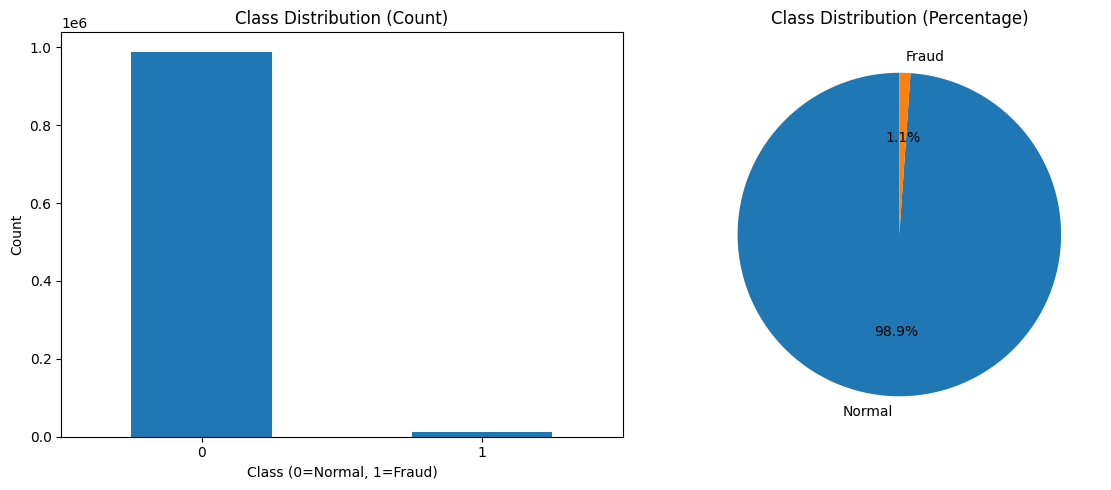

In [11]:
# Visualizziamo la distribuzione
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Grafico a barre
data['fraud_bool'].value_counts().plot(kind='bar', ax=ax1)
ax1.set_title('Class Distribution (Count)')
ax1.set_xlabel('Class (0=Normal, 1=Fraud)')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)

# Grafico a torta
class_counts = data['fraud_bool'].value_counts()
ax2.pie(class_counts.values, labels=['Normal', 'Fraud'], autopct='%1.1f%%', startangle=90)
ax2.set_title('Class Distribution (Percentage)')

plt.tight_layout()
plt.show()

<Axes: >

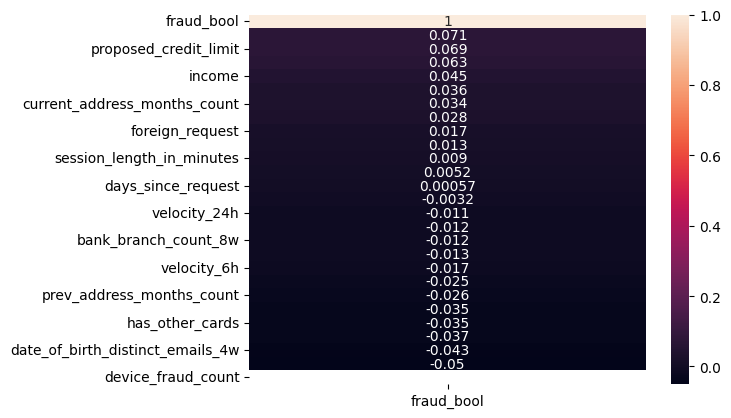

In [16]:
#Calcoliamo la matrice di correlazione per vedere quali feature numeriche sono più legate a fraud_bool

corr_matrix = data.corr(numeric_only=True)
sns.heatmap(corr_matrix[['fraud_bool']].sort_values(by='fraud_bool', ascending=False), annot=True)